[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IgnatiusEzeani/spatial-humanities-2026/blob/sh2026-workshop/workshop/05_affect_and_events.ipynb)

# 05 · Affect and narrator-centred events

**Spatial Humanities 2026 workshop**

This notebook examines sentiment, emotion and event extraction as **analytical annotations** rather than direct readings of human interior states.

## Learning goals
- compare transparent rule baselines with optional contextual/HF models;
- inspect exactly which lexical cues drive a rule result;
- identify domain assumptions and false positives;
- extract narrator-centred movement/action events;
- build a simple narrative-sequence view;
- distinguish computational affect labels from psychological ground truth.

> **Key message:** Richer annotation creates richer questions and richer risks.

In [1]:
!wget -q https://raw.githubusercontent.com/IgnatiusEzeani/spatial-humanities-2026/sh2026-workshop/workshop/sh2026_setup.py

import sh2026_setup as sh
ctx = sh.setup()

# Bound from the shared context: the cells below were written against these.
repo_dir = ctx.repo
data_dir = ctx.data

import json
REPO = "https://github.com/IgnatiusEzeani/spatio-textual.git"
FAST_MODE = True
print("Repository:", repo_dir)
print("Ready. FAST_MODE =", FAST_MODE)


Reusing existing checkout at /home/ezeani/workspace/spatial-humanities-2026
Dependencies already installed in this runtime.

Ready in 0s.
  repo    : /home/ezeani/workspace/spatial-humanities-2026
  commit  : 798f2be
  data    : /home/ezeani/workspace/spatial-humanities-2026/workshop/data
  outputs : /home/ezeani/workspace/spatial-humanities-2026/sh2026_outputs
  route   : CPU only, no API key needed

If this cell failed, put your hand up. Do not re-run it more than once.
Repository: /home/ezeani/workspace/spatial-humanities-2026
Ready. FAST_MODE = True


## 1. Public-safe teaching passages

These are instructor-created examples. They are designed to stress the methods without reproducing controlled testimony material.

In [2]:
segments = [
    "We reached the village at sunset and felt relieved to find shelter.",
    "The road was quiet and we waited beside the river.",
    "I was afraid as we crossed the dark forest, but later I felt safe.",
    "We left the village and walked to the station before returning home.",
    "The children returned happily from summer camp.",
]

for i, text in enumerate(segments):
    print(i, text)

0 We reached the village at sunset and felt relieved to find shelter.
1 The road was quiet and we waited beside the river.
2 I was afraid as we crossed the dark forest, but later I felt safe.
3 We left the village and walked to the station before returning home.
4 The children returned happily from summer camp.


## 2. Transparent rule-based sentiment

Rule baselines are valuable because we can inspect their assumptions directly. That transparency does not make the assumptions neutral.

In [3]:
from spatio_textual.sentiment import SentimentAnalyzer, POSITIVE, NEGATIVE, _tokens

sent_rule = SentimentAnalyzer(backend="rule")
sent_results = sent_rule.predict(segments)

def sentiment_evidence(text):
    toks = _tokens(text)
    return {
        "positive_terms": [t for t in toks if t in POSITIVE],
        "negative_terms": [t for t in toks if t in NEGATIVE],
    }

import pandas as pd

sent_table = []
for text, result in zip(segments, sent_results):
    sent_table.append({
        "text": text,
        "label": result["label"],
        "score": result["score"],
        **sentiment_evidence(text),
        "distribution": result["distribution"],
    })

display(pd.DataFrame(sent_table))

,text,label,score,positive_terms,negative_terms,distribution
0,We reached the village at sunset and felt reli...,mixed,0.4223,[relieved],[],"{'positive': 0.4223, 'negative': 0.1554, 'neut..."
1,The road was quiet and we waited beside the ri...,neutral,0.5761,[],[],"{'positive': 0.2119, 'negative': 0.2119, 'neut..."
2,"I was afraid as we crossed the dark forest, bu...",mixed,0.3333,[safe],[afraid],"{'positive': 0.3333, 'negative': 0.3333, 'neut..."
3,We left the village and walked to the station ...,neutral,0.5761,[],[],"{'positive': 0.2119, 'negative': 0.2119, 'neut..."
4,The children returned happily from summer camp.,mixed,0.4223,[],[camp],"{'positive': 0.1554, 'negative': 0.4223, 'neut..."


### Audit the result, not just the label

Look especially at the final sentence. The current domain-oriented lexicon contains **camp** as a negative cue. In a different domain, such as a summer-camp sentence, the same rule can become misleading.

This is a useful example of **domain assumption leakage**:

> a transparent rule can be easy to audit and still encode a theory or corpus-specific expectation.

Transparency helps us *find* the problem. It does not automatically solve it.

## 3. Rule-based emotion

The current rule backend uses an Ekman-style label inventory. We expose matched terms so you can inspect why a label was produced.

In [4]:
from spatio_textual.emotion import EmotionAnalyzer, LEXICON, _tokens as emotion_tokens

emo_rule = EmotionAnalyzer(backend="rule")
emo_results = emo_rule.predict(segments)

def emotion_evidence(text):
    toks = emotion_tokens(text)
    return {
        emotion: [t for t in toks if t in words]
        for emotion, words in LEXICON.items()
        if any(t in words for t in toks)
    }

emo_table = []
for text, result in zip(segments, emo_results):
    emo_table.append({
        "text": text,
        "label": result["label"],
        "score": result["score"],
        "matched_terms": emotion_evidence(text),
        "distribution": result["distribution"],
    })

display(pd.DataFrame(emo_table))

,text,label,score,matched_terms,distribution
0,We reached the village at sunset and felt reli...,mixed,0.2605,{'Joy': ['relieved']},"{'Neutral': 0.2605, 'Joy': 0.2605, 'Surprise':..."
1,The road was quiet and we waited beside the ri...,Neutral,0.3118,{},"{'Neutral': 0.3118, 'Joy': 0.1147, 'Surprise':..."
2,"I was afraid as we crossed the dark forest, bu...",mixed,0.2236,"{'Joy': ['safe'], 'Fear': ['afraid']}","{'Neutral': 0.2236, 'Joy': 0.2236, 'Surprise':..."
3,We left the village and walked to the station ...,Neutral,0.3118,{},"{'Neutral': 0.3118, 'Joy': 0.1147, 'Surprise':..."
4,The children returned happily from summer camp.,mixed,0.2605,{'Fear': ['camp']},"{'Neutral': 0.2605, 'Joy': 0.0958, 'Surprise':..."


### Interpretive caution

These outputs are best treated as:
- reproducible computational descriptors;
- prompts for corpus exploration;
- variables whose distribution can be compared across narrative segments.

They are **not** direct measurements of a narrator's psychological state.

Label choice, taxonomy, segmentation, lexical resources and training data all affect the result.

## 4. Optional contextual classifiers

If you have a suitable runtime and want a live comparison, switch `FAST_MODE = False`.

The default workshop path does **not** download transformer models. Instead it loads a precomputed output generated by the same pinned transformer condition used in the SH2026 affect experiment. The file records the exact model names, Hugging Face revisions, generation commit and original teaching passages. It is a reliability fallback, not a benchmark result.

When `FAST_MODE = False`, the notebook runs those same pinned models live so participants can compare the live and precomputed routes.

In [5]:
fallback_path = repo_dir / "demo" / "affect_transformer_teaching_fallback_v1.json"

if not FAST_MODE:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-transformers.txt"], check=True)
    from spatio_textual.affect_transformer import classify_affect_transformer
    transformer_rows = [
        {"segment_id": i, "text": text, **classify_affect_transformer(text)}
        for i, text in enumerate(segments)
    ]
    transformer_source = "live pinned transformer run"
else:
    fallback = json.loads(fallback_path.read_text(encoding="utf-8"))
    transformer_rows = fallback["records"]
    assert [row["text"] for row in transformer_rows] == segments
    transformer_source = "precomputed pinned transformer fallback"

comparison_rows = []
for i, (text, hf) in enumerate(zip(segments, transformer_rows)):
    comparison_rows.append({
        "segment": i,
        "text": text,
        "rule_sentiment": sent_results[i]["label"],
        "transformer_sentiment": hf["sentiment_label"],
        "rule_emotion": emo_results[i]["label"],
        "transformer_emotions": hf["emotion_labels"],
    })

display(pd.DataFrame(comparison_rows))
print("Transformer source:", transformer_source)
if FAST_MODE:
    print("Pinned revisions:", fallback["sentiment_revision"], fallback["emotion_revision"])

,segment,text,rule_sentiment,transformer_sentiment,rule_emotion,transformer_emotions
0,0,We reached the village at sunset and felt reli...,mixed,positive,mixed,[joy]
1,1,The road was quiet and we waited beside the ri...,neutral,neutral,Neutral,[fear]
2,2,"I was afraid as we crossed the dark forest, bu...",mixed,neutral,mixed,[fear]
3,3,We left the village and walked to the station ...,neutral,neutral,Neutral,[fear]
4,4,The children returned happily from summer camp.,mixed,positive,mixed,[joy]


Transformer source: precomputed pinned transformer fallback
Pinned revisions: 3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7 0e1cd914e3d46199ed785853e12b57304e04178b


## 5. Narrator-centred events

Entity extraction tells us *what is mentioned*. Event extraction begins to ask *what the narrator does or experiences*.

We keep event evidence tied to the source text and avoid turning every verb into a historical claim.

In [6]:
from spatio_textual.utils import load_spacy_model, Annotator

narrative = (
    "I left the village and walked to the river. "
    "We waited there until evening. "
    "Then we returned home."
)

nlp = load_spacy_model("en_core_web_sm", add_entity_ruler=True)
annotator = Annotator(nlp=nlp, model_name="en_core_web_sm", link_places=False)
event_record = annotator.annotate(
    narrative,
    include_entities=True,
    include_verbs=True,
    include_events=True,
    include_text=True,
)

print("Narrative:", narrative)
print("\nNarrator-centred events:")
display(pd.DataFrame(event_record["event_data"]))

/home/ezeani/workspace/spatial-humanities-2026/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Narrative: I left the village and walked to the river. We waited there until evening. Then we returned home.

Narrator-centred events:


,event,lemma,event_type,subject,first_person_subject,first_person_object,start_char,end_char,confidence,source
0,left,leave,narrator_action,[I],True,False,2,6,0.90,dependency
1,walked,walk,movement_or_experience_fallback,[],False,False,23,29,0.55,lexical_fallback
2,waited,wait,narrator_action,[We],True,False,47,53,0.90,dependency
3,returned,return,narrator_action,[we],True,False,83,91,0.90,dependency


If `en_core_web_sm` is not installed, the package falls back safely to a lightweight pipeline. The fallback can still identify some motion/experience cues, but dependency-based subject interpretation will be weaker. That runtime distinction should be recorded in telemetry.

In [7]:
print("Telemetry:")
print(json.dumps(event_record["telemetry"], indent=2))

Telemetry:
[
  {
    "task": "spatial_entity_recognition",
    "backend": "spacy",
    "provider": "local",
    "model": "en_core_web_sm",
    "latency_ms": 6.622,
    "input_chars": 97,
    "input_tokens_est": 24,
    "output_tokens_est": 128,
    "cost_usd_est": 0.0,
    "success": true,
    "error": null
  }
]


## 6. Narrative sequence, not a diagnosis

A simple plot can show how a classifier's outputs change across segments. The y-axis below represents the rule model's **negative probability**, not a person's emotional intensity.

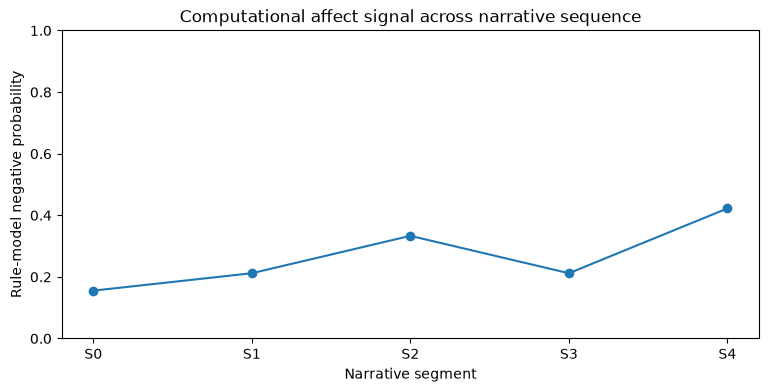

In [8]:
import matplotlib.pyplot as plt

negative_probability = [r["distribution"]["negative"] for r in sent_results]

plt.figure(figsize=(9, 4))
plt.plot(range(len(segments)), negative_probability, marker="o")
plt.xticks(range(len(segments)), [f"S{i}" for i in range(len(segments))])
plt.xlabel("Narrative segment")
plt.ylabel("Rule-model negative probability")
plt.title("Computational affect signal across narrative sequence")
plt.ylim(0, 1)
plt.show()

## 7. Error-analysis exercise

For each output, ask:

1. **Selection:** did the system analyse the right textual unit?
2. **Ontology:** are these sentiment/emotion labels appropriate for the research question?
3. **Evidence:** which words or contextual features drove the result?
4. **Domain:** is the model carrying assumptions from another corpus?
5. **Interpretation:** what scholarly claim would be justified, and what would overreach?

Suggested challenge: rewrite one sentence so that the *human interpretation* remains similar while the rule result changes substantially.

In [9]:
challenge = {
    "original": "The children returned happily from summer camp.",
    "rewrite":  "The children came back cheerful after their summer programme.",
}

for label, text in challenge.items():
    s = sent_rule.predict([text])[0]
    e = emo_rule.predict([text])[0]
    print(label, "=>", {
        "sentiment": s["label"],
        "emotion": e["label"],
        "sentiment_evidence": sentiment_evidence(text),
        "emotion_evidence": emotion_evidence(text),
    })

original => {'sentiment': 'mixed', 'emotion': 'mixed', 'sentiment_evidence': {'positive_terms': [], 'negative_terms': ['camp']}, 'emotion_evidence': {'Fear': ['camp']}}
rewrite => {'sentiment': 'neutral', 'emotion': 'Neutral', 'sentiment_evidence': {'positive_terms': [], 'negative_terms': []}, 'emotion_evidence': {}}


## 8. Take-away

Affect and event extraction can enrich spatial narratives by connecting:

**where → what happened → how the passage is computationally characterised**

But every added layer introduces assumptions about segmentation, ontology, domain, evidence and interpretation.

**Next:** evidence-first LLM structured extraction, where we explicitly separate model proposal from source-grounded validation.